<a href="https://colab.research.google.com/github/shivansh2310/The-elements-of-quantitative-investing-/blob/main/Statistical_Factor_Models_(Chapter_7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## The Theory: Core Concepts for Your Notes

* The Difference: In Fundamental models, your factors ($f$) have names (e.g., "Value"). In Statistical models, your factors are eigenvectors. They are mathematically "cleaner" because they are orthogonal by construction, but they are often "anonymous."

* The Tool (PCA): Principal Component Analysis is the primary engine.

  * Eigenvalues: Represent the % of total variance explained by each factor.

  * Eigenvectors: The weights (loadings) that define the "portfolio" of stocks creating that factor.

* The "Scree Plot" (The Elbow Method): You don't keep all 20 factors. You look at the drop-off in explained variance. The point where the curve flattens (the "elbow") is usually where you stop, as the remaining factors are likely just noise.

* Rank Deficiency: A recurring theme—if you have 20 stocks but only 10 days of data, your covariance matrix is rank-deficient (max rank 10). PCA handles this by collapsing the system into its core components.


## PCA Factor Extraction

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
def data(tickers):
  hist_data = yf.download(tickers, period="2y")['Close'].pct_change().dropna()
  X_std = StandardScaler().fit_transform(hist_data)
  return X_std

stock_data = {
    "MSFT": "Tech", "NVDA": "Tech", "AAPL": "Tech",
    "NEE": "Utilities", "AEP": "Utilities", "VST": "Utilities",
    "CAT": "Industrials", "GE": "Industrials", "PWR": "Industrials",
    "JPM": "Financials", "GS": "Financials", "V": "Financials",
    "XOM": "Energy", "CVX": "Energy",
    "META": "Comm", "GOOGL": "Comm",
    "LLY": "Healthcare", "UNH": "Healthcare",
    "AMZN": "Consumer", "WMT": "Consumer"
}

tickers = list(stock_data.keys())

X_std = data(tickers)
X_std.shape

/tmp/ipykernel_3560/2500113039.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist_data = yf.download(tickers, period="2y")['Close'].pct_change().dropna()
[*********************100%***********************]  20 of 20 completed


(499, 20)

In [13]:
stock_data.items()

dict_items([('MSFT', 'Tech'), ('NVDA', 'Tech'), ('AAPL', 'Tech'), ('NEE', 'Utilities'), ('AEP', 'Utilities'), ('VST', 'Utilities'), ('CAT', 'Industrials'), ('GE', 'Industrials'), ('PWR', 'Industrials'), ('JPM', 'Financials'), ('GS', 'Financials'), ('V', 'Financials'), ('XOM', 'Energy'), ('CVX', 'Energy'), ('META', 'Comm'), ('GOOGL', 'Comm'), ('LLY', 'Healthcare'), ('UNH', 'Healthcare'), ('AMZN', 'Consumer'), ('WMT', 'Consumer')])

In [5]:
X_std

array([[ 4.0171532 , -0.21070923,  0.00768693, ...,  0.81441049,
        -0.31593241, -0.58470483],
       [ 1.54389203, -0.50553354, -0.1255125 , ..., -0.23000197,
        -0.506059  , -0.78261204],
       [ 0.2482308 , -0.13514001, -0.83715576, ..., -0.65080297,
         0.30349398, -0.58310346],
       ...,
       [ 0.11551933,  0.90664746,  0.70039358, ..., -0.06324   ,
         0.39594378, -0.26652025],
       [-0.76137491,  0.80976735, -1.53148665, ..., -0.86072032,
         0.55622293, -0.97274106],
       [-1.11901433, -1.61983956, -0.19768436, ..., -0.36341606,
         0.44378417,  0.7482125 ]])

In [6]:
pca = PCA()
pca.fit(X_std)

PCA()

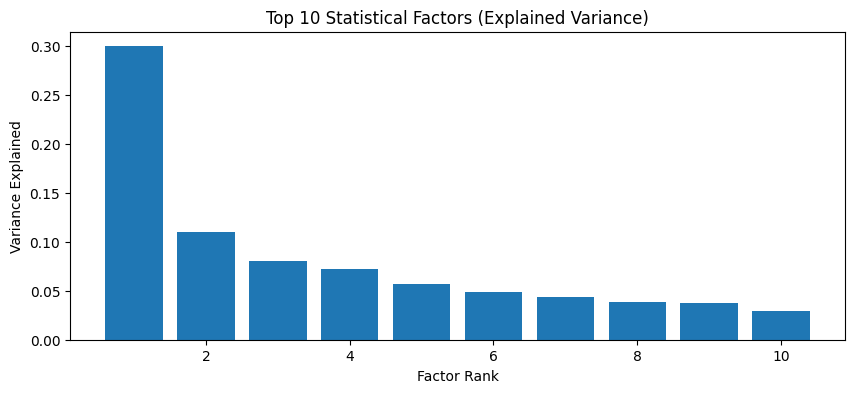

In [7]:
plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10])
plt.title("Top 10 Statistical Factors (Explained Variance)")
plt.xlabel("Factor Rank")
plt.ylabel("Variance Explained")
plt.show()

In [8]:
print("Factor 1 Loadings (The Market):")
print(pd.Series(pca.components_[0], index=tickers).sort_values(ascending=False))

Factor 1 Loadings (The Market):
GE       0.323483
AAPL     0.293246
PWR      0.289873
NEE      0.280029
CVX      0.279876
VST      0.276408
GS       0.269710
META     0.258627
MSFT     0.257643
CAT      0.256100
UNH      0.247872
V        0.234128
LLY      0.207572
AMZN     0.137681
AEP      0.124764
JPM      0.121021
WMT      0.083547
XOM      0.062648
GOOGL    0.033899
NVDA    -0.005327
dtype: float64


In [10]:
print("Factor 2 Loadings (The Market):")
print(pd.Series(pca.components_[1], index=tickers).sort_values(ascending=False))

Factor 2 Loadings (The Market):
WMT      0.473027
AEP      0.436750
NVDA     0.403741
XOM      0.355164
AMZN     0.178133
LLY      0.175829
PWR      0.134041
NEE      0.120425
JPM      0.082515
GOOGL    0.082482
GE       0.044831
MSFT     0.032266
VST     -0.003827
META    -0.058590
UNH     -0.094529
AAPL    -0.149099
CAT     -0.161380
GS      -0.181281
V       -0.212218
CVX     -0.214502
dtype: float64
